# ==========================================
# 10 Academy AI Mastery — Week 9 Challenge
# Task 5: Strategy Backtesting Framework
# ==========================================

--- Step 1: Loading Out-of-Sample Backtest Window ---


[*********************100%***********************]  3 of 3 completed


Backtest Timeline Span: 2025-01-02 to 2026-06-29
Total Trading Days in Evaluation: 371 days

--- Step 2: Configuring Strategies & Allocation Weights ---
Target Strategy Allocation Weights : BND=45.0%, SPY=42.5%, TSLA=12.5%
Passive Benchmark Allocation Weights: BND=40.0%, SPY=60.0%, TSLA=0.0%

--- Step 3: Running Algorithmic Rebalancing Simulation ---
--- Step 4: Computing Advanced Analytical Risk Metrics ---

================= STRATEGY BACKTEST RESULTS =================
                        GMF Optimized Strategy Passive 60/40 Benchmark
Total Cumulative Return                 18.78%                  20.62%
Annualized Return                       12.40%                  13.58%
Annualized Volatility                   13.66%                  11.07%
Sharpe Ratio (Rf=0)                      0.907                   1.227
Maximum Drawdown                       -13.77%                 -11.25%


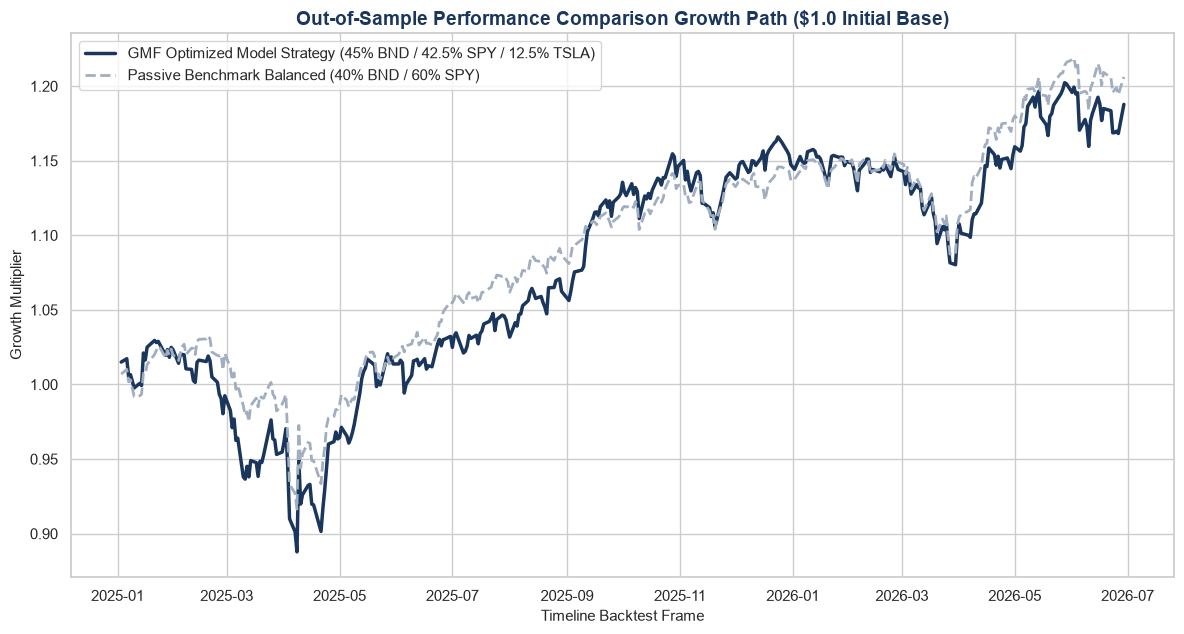

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional visualization layout
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 7]

# ==========================================
# STEP 1: Define Period and Download Data
# ==========================================
print("--- Step 1: Loading Out-of-Sample Backtest Window ---")
tickers = ['TSLA', 'BND', 'SPY']

# Fetch the raw data
data = yf.download(tickers, start='2015-01-01', end='2026-06-30')

# Extract either 'Adj Close' or 'Close' cleanly using cross-section fallback
if data.columns.nlevels > 1:
    target_col = 'Adj Close' if 'Adj Close' in data.columns.levels[0] else 'Close'
    raw_data = data.xs(target_col, axis=1, level=0)
else:
    target_col = 'Adj Close' if 'Adj Close' in data.columns else 'Close'
    raw_data = data[target_col]

raw_data = raw_data.ffill().bfill()

# Backtest period: January 2025 through June 2026 (Unseen Out-of-Sample Data)
backtest_prices = raw_data.loc['2025-01-01':'2026-06-30']
daily_returns = backtest_prices.pct_change().dropna()

print(f"Backtest Timeline Span: {backtest_prices.index[0].strftime('%Y-%m-%d')} to {backtest_prices.index[-1].strftime('%Y-%m-%d')}")
print(f"Total Trading Days in Evaluation: {len(daily_returns)} days\n")

# ==========================================
# STEP 2: Define Allocations & Rebalancing Rules
# ==========================================
print("--- Step 2: Configuring Strategies & Allocation Weights ---")

# Strategy Target Portfolio (From Task 4 Optimized Outputs)
# Order matches columns alphabetized by pandas: BND, SPY, TSLA
strategy_weights = np.array([0.45, 0.425, 0.125]) 

# Benchmark Portfolio: Standard Balanced 60% Equities (SPY) / 40% Bonds (BND)
# Order: BND=0.40, SPY=0.60, TSLA=0.00
benchmark_weights = np.array([0.40, 0.60, 0.00])

print(f"Target Strategy Allocation Weights : BND={strategy_weights[0]*100}%, SPY={strategy_weights[1]*100}%, TSLA={strategy_weights[2]*100}%")
print(f"Passive Benchmark Allocation Weights: BND={benchmark_weights[0]*100}%, SPY={benchmark_weights[1]*100}%, TSLA={benchmark_weights[2]*100}%\n")

# ==========================================
# STEP 3: Simulate Portfolios (Vectorized Monthly Rebalancing Engine)
# ==========================================
print("--- Step 3: Running Algorithmic Rebalancing Simulation ---")

def simulate_portfolio(returns_df, target_weights):
    """
    Simulates portfolio performance via fast vectorized monthly blocks.
    Rebalances back to target weights automatically at the start of each month.
    """
    portfolio_values = [1.0] # Initial starting cash scaled to 1.0
    current_target_weights = np.array(target_weights)
    
    # Group the returns by Year and Month
    grouped_months = returns_df.groupby([returns_df.index.year, returns_df.index.month])
    
    for (year, month), month_returns in grouped_months:
        # Calculate daily cumulative growth profile for all individual assets this month
        asset_cumulative_growth = (1.0 + month_returns).cumprod()
        
        # Apply the starting weights to track asset drift across the month
        drifted_portfolio_growth = asset_cumulative_growth * current_target_weights
        
        # Sum across assets to get the collective monthly portfolio growth curve
        monthly_profile = drifted_portfolio_growth.sum(axis=1)
        
        # Scale the monthly profile by the end value of the last month
        starting_capital_this_month = portfolio_values[-1]
        actual_monthly_values = starting_capital_this_month * monthly_profile
        
        # Record performance data
        portfolio_values.extend(actual_monthly_values.tolist())
        
        # Rebalancing occurs implicitly here: the next loop starts clean with original target weights
        
    return pd.Series(portfolio_values[1:], index=returns_df.index)

# Execute simulations instantly
strategy_equity_curve = simulate_portfolio(daily_returns, strategy_weights)
benchmark_equity_curve = simulate_portfolio(daily_returns, benchmark_weights)

# ==========================================
# STEP 4: Performance Metric Engine Calculations
# ==========================================
print("--- Step 4: Computing Advanced Analytical Risk Metrics ---")

def calculate_metrics(equity_curve, daily_returns_series):
    # Total Return
    total_return = (equity_curve.iloc[-1] - 1.0) * 100
    
    # Annualized Return (252 trading days per calendar year layout)
    days = len(equity_curve)
    annualized_return = ((equity_curve.iloc[-1]) ** (252.0 / days) - 1.0) * 100
    
    # Portfolio Daily Returns for Sharpe tracking
    portfolio_daily_pct = equity_curve.pct_change().dropna()
    annualized_volatility = portfolio_daily_pct.std() * np.sqrt(252) * 100
    
    # Sharpe Ratio (Assuming Risk-Free Rate = 0.0%)
    sharpe_ratio = (annualized_return / annualized_volatility) if annualized_volatility != 0 else 0
    
    # Maximum Drawdown
    rolling_peak = equity_curve.cummax()
    drawdowns = (equity_curve - rolling_peak) / rolling_peak
    max_drawdown = drawdowns.min() * 100
    
    return total_return, annualized_return, annualized_volatility, sharpe_ratio, max_drawdown

# Compute metric tuples
strat_metrics = calculate_metrics(strategy_equity_curve, daily_returns)
bench_metrics = calculate_metrics(benchmark_equity_curve, daily_returns)

# Construct comparison summary dataframe table
metrics_df = pd.DataFrame({
    'GMF Optimized Strategy': [f"{strat_metrics[0]:.2f}%", f"{strat_metrics[1]:.2f}%", f"{strat_metrics[2]:.2f}%", f"{strat_metrics[3]:.3f}", f"{strat_metrics[4]:.2f}%"],
    'Passive 60/40 Benchmark': [f"{bench_metrics[0]:.2f}%", f"{bench_metrics[1]:.2f}%", f"{bench_metrics[2]:.2f}%", f"{bench_metrics[3]:.3f}", f"{bench_metrics[4]:.2f}%"]
}, index=['Total Cumulative Return', 'Annualized Return', 'Annualized Volatility', 'Sharpe Ratio (Rf=0)', 'Maximum Drawdown'])

print("\n================= STRATEGY BACKTEST RESULTS =================")
print(metrics_df)
print("=============================================================")

# ==========================================
# STEP 5: Visualize Cumulative Performance Curves
# ==========================================
plt.figure(figsize=(12, 6.5))
plt.plot(strategy_equity_curve, label='GMF Optimized Model Strategy (45% BND / 42.5% SPY / 12.5% TSLA)', color='#1A365D', linewidth=2.5)
plt.plot(benchmark_equity_curve, label='Passive Benchmark Balanced (40% BND / 60% SPY)', color='#A0AEC0', linewidth=2, linestyle='--')

plt.title("Out-of-Sample Performance Comparison Growth Path ($1.0 Initial Base)", fontsize=14, fontweight='bold', color='#1A365D')
plt.xlabel("Timeline Backtest Frame", fontsize=11)
plt.ylabel("Growth Multiplier", fontsize=11)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()